# Домашнее задание: Предварительная обработка, частоты и морфология в 'Мцыри'

В этом ДЗ вы закрепите навыки из трех тем: предобработка текстов, анализ частот слов и морфологический анализ. Работайте с первыми двумя главами поэмы М.Ю. Лермонтова 'Мцыри'. Выполните базовые задачи, а затем более сложные — с визуализацией и интерпретацией для цифровых гуманитарных исследований. Обработайте и проанализируйте стиль Лермонтова (например, частые глаголы движения для темы 'побега').

**NB! Вы можете использовать свой текст (или полный текст Лермонтова), но тогда вам нужно продумать свою систему исследования, виды глаголов и т.д. Будьте внимательны!**

**Дедлайн: 2.03.2026**

Загрузите результат в любой доступный вам репозиторий и добавьте ссылку в эту таблицу: https://docs.google.com/spreadsheets/d/1C7USVMEkisfqe4l51g_yQX6kbtJYqviPXBIG1c0pc1o/edit?usp=sharing. Если репозиторий закрытый, то зашерьте его на почту a.klimov@hse.ru или aleksklimow@gmail.com. Постарайтесь по возможности оформить работу с файлами так, чтобы это было достаточно легко проверить.

*Не забывайте импортировать библиотеки: `import re`, `import nltk`, `from nltk.corpus import stopwords`, `nltk.download('stopwords')`, `from collections import Counter`, `import matplotlib.pyplot as plt` (для визуализации), `from pymorphy2 import MorphAnalyzer`.*

In [26]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from collections import Counter


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [51]:
import matplotlib.pyplot as plt
import pandas as pd

In [81]:
#!pip install pymorphy2
#!pip install pymorphy2-dicts
#!pip install --upgrade pymorphy2 pymorphy2-dicts

import pymorphy2
from pymorphy2 import MorphAnalyzer

In [2]:
with open('full_text.txt', 'r', encoding='utf-8') as file:
    text = file.read()

In [4]:
print(text[-200:])

мать я, что друг
Иль брат, склонившись надо мной,
Отер внимательной рукой.
С лица кончины хладный пот
И что вполголоса поет
Он мне про милую страну...
И с этой мыслью я засну,
И никого не прокляну!..»


## Задание 1: Регулярные выражения

1. Напишите регулярное выражение, которое найдет все слова, начинающиеся с "ста".
2. Расширьте: найдите слова с "ста" внутри (не только в начале).
3. Модернизируйте: сделайте 'т' опциональной (замените на любой символ: [а-ят]?).

Ожидаемый вывод: список найденных слов, например, ['старик', 'старый'].

In [7]:
print("1. Слова, начинающиеся с 'ста':")
pattern1 = r'\bста[а-я]+'
words1 = re.findall(pattern1, text)
print(words1)

1. Слова, начинающиеся с 'ста':
['старик', 'стал', 'старик', 'старик', 'стало', 'стариков', 'старости', 'стало', 'стал', 'стал', 'стал', 'стал', 'стал', 'старик', 'стал', 'стал', 'стало', 'стада', 'стану', 'стану']


In [8]:
print("2. Слова с 'ста' внутри:")
pattern2 = r'[а-я]*ста[а-я]*'
words2 = re.findall(pattern2, text)
print(words2)

2. Слова с 'ста' внутри:
['старик', 'остался', 'стал', 'ривстал', 'остаток', 'старик', 'расстаться', 'старик', 'стало', 'стариков', 'старости', 'устав', 'стало', 'стал', 'кустам', 'стал', 'стал', 'ростая', 'настает', 'стал', 'куста', 'стал', 'старик', 'стал', 'стал', 'остаток', 'стал', 'стало', 'ставила', 'усталую', 'кустах', 'встать', 'хрусталь', 'стада', 'станься', 'усталый', 'остальное', 'стану', 'куста', 'густа', 'стану']


In [9]:
print("3. Слова, где 'т' опциоинальная:")
pattern3 = r'[а-я]*ст?а[а-я]*'
words3 = re.findall(pattern3, text)
print(words3)

3. Слова, где 'т' опциоинальная:
['старик', 'садов', 'опасаяся', 'остался', 'стал', 'ривстал', 'остаток', 'старик', 'расстаться', 'старик', 'стало', 'стариков', 'касалися', 'старости', 'устав', 'сам', 'стало', 'сад', 'стал', 'голосам', 'кустам', 'голоса', 'стал', 'стал', 'ростая', 'настает', 'сакли', 'сакле', 'небесах', 'стал', 'куста', 'стал', 'старик', 'стал', 'сам', 'стал', 'остаток', 'стал', 'стало', 'ставила', 'сад', 'усталую', 'кустах', 'небесах', 'встать', 'хрусталь', 'стада', 'станься', 'усталый', 'остальное', 'сам', 'стану', 'сад', 'куста', 'густа', 'стану', 'вполголоса']


## Задание 2: Нормализация текста

1. Приведите текст к нижнему регистру.
2. Удалите пунктуацию и \n с помощью regex (используйте `re.sub(r'[^а-яё\s]', ' ', text.lower())` как основу).

Сохраните нормализованный текст в `normalized_text`.

In [21]:
#удаляем пунктуацию
normalized_text = re.sub(r'[^а-яё\s]', ' ', text.lower())

In [22]:
#приводим все к одной строке
normalized_text = re.sub(r'\n', ' ', normalized_text)

In [23]:
#удаляем лишние пробелы после удаления пунктуации
normalized_text = re.sub(r' +', ' ', normalized_text)

In [24]:
print(normalized_text[-200:])

 и стану думать я что друг иль брат склонившись надо мной отер внимательной рукой с лица кончины хладный пот и что вполголоса поет он мне про милую страну и с этой мыслью я засну и никого не прокляну 


## Задание 3: Токенизация

1. Токенизируйте `normalized_text` на слова (используйте `re.findall(r'\w+', normalized_text)`). Подсчитайте общее число токенов и уникальных (используйте `set` или `Counter`).
2. Токенизируйте оригинальный `text` на строки (`split('\n')`). Сколько строк?
3. Напишите цикл: сохраните слова с заглавной буквы (из оригинального текста).
4. Модернизируйте цикл: исключите первые слова строк (используйте `line.split()` и проверку позиции).

Ожидаемый вывод: len(tokens), len(set(tokens)), список имен/заголовков.

In [31]:
#токенизируем текст
tokens = re.findall(r'\w+', normalized_text)

#считаем
print(f'Общее число токенов: {len(tokens)}')
print(f'Уникальных токенов: {len(set(tokens))}')

Общее число токенов: 3353
Уникальных токенов: 1661


In [28]:
#токенизируем оригинальный текст
print(f'Число строк в исходном тексте: {len(text.split('\n'))}')

Число строк в исходном тексте: 778


In [33]:
#циклом вытаскиваем слова с заглавной буквы
all_words = re.findall(r'\w+', text)
capital_words = []

for word in all_words:
    if word[0].isupper():  #проверяем, что первая буква заглавная
        capital_words.append(word)

In [34]:
print(capital_words[:10])

['Немного', 'Там', 'Обнявшись', 'Струи', 'Арагвы', 'Куры', 'Был', 'Из', 'И', 'Столбы']


In [37]:
#переделываем цикл, чтобы не учитывать первое слово в строке
lines = text.split('\n')
new_capital_words = []

for line in lines:
  words_in_line = line.split()
  words_in_line = words_in_line[1:] #выкидываем первое слово каждой строки
  for word in words_in_line:
    if word[0].isupper():  #проверяем, что первая буква заглавная
        new_capital_words.append(word)

In [38]:
print(new_capital_words[:10])

['Арагвы', 'Куры,', 'Из-за', 'России', 'Грузию!', 'Она', 'Тифлису', 'Без', 'Темный', 'Угрюм']


## Задание 4: Удаление стоп-слов

1. Импортируйте стоп-слова NLTK для русского.
2. Создайте список токенов без стоп-слов (цикл или list comprehension).
3. Подсчитайте оставшиеся токены и уникальные.
4. Добавьте к стоп-словам слова с 'бол' (опциональная 'о': regex `r'\w*б[о]?л\w*'`). Удалите их. Сколько осталось?

Сохраните в `filtered_tokens`.

In [39]:
russian_stopwords = stopwords.words('russian')
print(russian_stopwords[:10])

['и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со']


In [40]:
#убираем стоп-слова из tokens

meaningful_tokens = []
for token in tokens:
    if token not in russian_stopwords:
        meaningful_tokens.append(token)

In [41]:
print(f'Осталось токенов: {len(meaningful_tokens)}')
print(f'Из них уникальных: {len(set(meaningful_tokens))}')

Осталось токенов: 2139
Из них уникальных: 1537


In [42]:
print(meaningful_tokens[:10])

['немного', 'лет', 'тому', 'назад', 'сливаяся', 'шумят', 'обнявшись', 'две', 'сестры', 'струи']


In [45]:
#убираем слова с "бо?л"

filtered_tokens = []
for token in meaningful_tokens:
  if re.search(r'\w*б[о]?л\w*', token) == None:
    filtered_tokens.append(token)


In [46]:
print(f'Осталось токенов: {len(filtered_tokens)}')
print(f'Из них уникальных: {len(set(filtered_tokens))}')

Осталось токенов: 2109
Из них уникальных: 1513


## Задание 5: Частотный анализ

1. Используйте `Counter` на `filtered_tokens`: выведите топ-10 самых частых слов.
2. Визуализируйте: Постройте барчарт топ-10 (matplotlib: `plt.bar()`). Подпишите оси ('Слова', 'Частота').
3. Гуманитарная интерпретация: Разделите текст на две главы (используйте индекс поиска 'Глава 2' или вручную). Сравните топ-5 частых слов в каждой (Counter для каждой главы). Что это говорит о темах? (Например, в первой — 'монастырь/плен', во второй — 'свобода/бег').

*Ожидаемый вывод: Таблица сравнения (используйте pandas.DataFrame для топ-5).*

In [47]:
# Ваш код здесь
freq = Counter(filtered_tokens)
print(freq.most_common(10))

[('лишь', 12), ('мог', 11), ('грудь', 10), ('мной', 10), ('меж', 10), ('стал', 9), ('долго', 8), ('мою', 8), ('жил', 8), ('б', 8)]


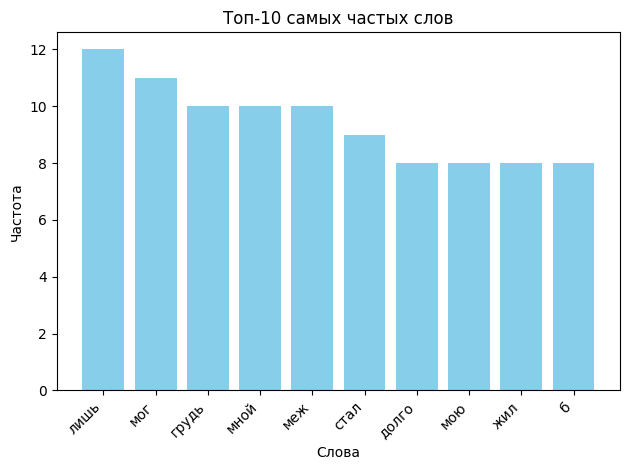

In [50]:
#строим график

top_10 = freq.most_common(10)
words, counts = zip(*top_10)

plt.bar(words, counts, color='skyblue')
plt.title('Топ-10 самых частых слов')
plt.xlabel('Слова')
plt.ylabel('Частота')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [52]:
#не очень поняла про две главы, поэтому просто делю список токенов пополам
first_part = filtered_tokens[:len(filtered_tokens) // 2]
second_part = filtered_tokens[len(filtered_tokens) // 2:]

In [53]:
print(first_part[:10])
print(second_part[:10])


['немного', 'лет', 'тому', 'назад', 'сливаяся', 'шумят', 'обнявшись', 'две', 'сестры', 'струи']
['шла', 'тише', 'легко', 'стройна', 'ношею', 'своей', 'тополь', 'царь', 'полей', 'недалеко']


In [55]:
#частоты для каждой части

freq_first = Counter(first_part)
freq_second = Counter(second_part)

In [66]:
freqs_comparison = {
    'Слово из 1 части': [word for word, count in freq_first.most_common(5)],
    'Частота (1)': [count for word, count in freq_first.most_common(5)],
    'Слово из 2 части': [word for word, count in freq_second.most_common(5)],
    'Частота (2)': [count for word, count in freq_second.most_common(5)]
}

df_comparison = pd.DataFrame(freqs_comparison)
display(df_comparison)

,Слово из 1 части,Частота (1),Слово из 2 части,Частота (2)
0,жил,7,мной,7
1,лишь,6,мог,6
2,меж,6,грудь,6
3,час,5,долго,6
4,стал,5,лишь,6


**Вывод**: если честно, это ничего не говорит о разнице в темах между двумя частями. Чтобы можно было сделать такой вывод, нужно расширить список стоп-слов и убрать большее их количество (например, "лишь", "меж", "мной" не несут смысловой нагрузки)

## Задание 6: Морфологический анализ

1. Инициализируйте `MorphAnalyzer` из pymorphy2. Проанализируйте POS (часть речи) для топ-10 частых слов из Задания 5 (`.tag.POS` или `.parse(word)[0].tag.POS`).
2. Создайте Counter для частей речи во всем `filtered_tokens` (цикл: для каждого токена — morph.parse(word)[0].tag.POS). Выведите топ-3 (существительные? глаголы?).
3. Найдите все глаголы движения ('бежать', 'мчаться' и т.п. — используйте regex `r'\b[бмп]е[жз]у?\w*'`) и их формы (morph.normal_form). Сколько уникальных лемм? Как это отражает тему 'побега' в 'Мцыри'?

*Ожидаемый вывод: Словарь {POS: count}, список лемм глаголов.*

In [85]:
#!pip install pymorphy3
#import pymorphy3

#тут у меня никакими правдами и неправдами не хотел работать pymorphy2,
#но заработал pymorphy3

morph = pymorphy3.MorphAnalyzer()

In [87]:
df_top10 = {
    'Слово': [word for word, count in top_10],
    'Частота': [count for word, count in top_10],
    'Часть речи': [morph.parse(word)[0].tag.POS for word, count in top_10]
    }

df_top10 = pd.DataFrame(df_top10)
display(df_top10)

,Слово,Частота,Часть речи
0,лишь,12,PRCL
1,мог,11,VERB
2,грудь,10,NOUN
3,мной,10,NPRO
4,меж,10,PREP
5,стал,9,VERB
6,долго,8,ADVB
7,мою,8,ADJF
8,жил,8,VERB
9,б,8,PRCL


In [88]:
pos_counter = Counter()
for word in filtered_tokens:
    pos_counter[morph.parse(word)[0].tag.POS] += 1

print(dict(pos_counter.most_common(3)))

{'NOUN': 881, 'VERB': 403, 'ADJF': 389}


## Задание 7: Интеграция и интерпретация

1. Соберите пайплайн: Обработайте полный текст (объедините главы), создайте 'чистый' корпус (нормализация + фильтрация + лемматизация с pymorphy2). В этом случае можно использовать нестандартные решения, которые мы изучали бегло или только упоминали.
2. Сравнительный анализ: Вычислите TF-IDF для двух глав (используйте простой расчет: freq_in_doc / log(total_docs / docs_with_word)). Выведите топ-3 уникальных слова для каждой главы.
3. Визуализация стиля: Постройте word cloud. Сравните облака для глав.
4. Вывод: В 100–200 словах опишите, как обработка раскрывает романтизм Лермонтова (контраст 'плена' и 'свободы').

In [ ]:
# Ваш код здесь
